# K-means 方法的实现及其在 iris 数据集上的应用

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 加载 iris 数据集
iris = datasets.load_iris()
x_iris = iris.data
y_iris = iris.target
x_iris_train, x_iris_test, y_iris_train, y_iris_test = train_test_split(x_iris, y_iris, test_size = 0.3, random_state = 42)

In [10]:
import random
import re
from collections import Counter
from typing import List

size = len(x_iris)
type = len(x_iris[0])

N = 100

## 1. 现成 sklearn 库的使用

In [ ]:
from sklearn.cluster import KMeans

n = 3
kmeans = KMeans(n_clusters = n, random_state = 1)
kmeans.fit(x_iris_train, y_iris_train)
y_iris_pred = kmeans.predict(x_iris_test)
print(f'n_clusters = {n}，准确率：{accuracy_score(y_iris_test, y_iris_pred)}')

n_clusters = 3，准确率：0.9333333333333333


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 2 手动复现 k-means 分类器

In [12]:
def random_state_write(N_new:int, size_new:int, range_new:int, filename:str) -> None:
    ''' 根据 N, size, range 进行 random_state 打表，并写入文件 '''
    is_empty = False
    N_s_r_str = ''
    is_same = False
    with open(filename, 'r', encoding='utf-8') as f:
        N_s_r_str = f.readline()
        if N_s_r_str == '':
            is_empty = True
        else:
            N_s_r = [int(i) for i in re.findall(r'\d+', N_s_r_str)]
            if N_s_r[0] == N_new and N_s_r[1] == size_new and N_s_r[2] == range_new:
                is_same = True
    if is_empty or (not is_empty and not is_same):
        with open(filename, 'w', encoding='utf-8') as f:
            f.write('N = %d, size = %d, range = %d\n' % (N_new, size_new, range_new))
            for i in range(N_new):
                f.write(str(random.sample(range(range_new), size_new)))
                f.write('\n')

def random_state_read(random_state:int, filename:str) -> List[int]:
    ''' 根据 random_state 从文件中读取随机种子 '''
    with open(filename, 'r', encoding='utf-8') as f:
        random_state_list = f.readline()
        for i in range(random_state + 1):
            random_state_list = f.readline()
    return [int(i) for i in re.findall(r'\d+', random_state_list)]

In [13]:
def train_test_split(x, y, test_size:float, random_state:int):
    ''' 将数据集划分为训练集和测试集 '''
    size_test = int(np.ceil(size * test_size))
    size_train = size - size_test
    random_state_write(N, size_test, size, 'random_split.txt')
    list_test = random_state_read(random_state, 'random_split.txt')
    x_test = np.zeros((size_test, type))
    y_test = np.zeros(size_test, int)
    for i in range(size_test):
        x_test[i] = x[list_test[i]]
        y_test[i] = y[list_test[i]]
    list_train = [i for i in range(size) if i not in list_test]
    x_train = np.zeros((size_train, type))
    y_train = np.zeros(size_train, int)
    for i in range(size_train):
        x_train[i] = x[list_train[i]]
        y_train[i] = y[list_train[i]]
    return x_train, x_test, y_train, y_test

In [14]:
class Kmeans:
    ''' 复现 KMeans 类，带 fit, predict 函数 '''
    def __init__(self, n_clusters, random_state):
        self.K = n_clusters
        self.random_state = random_state

    def fit(self, x_train, y_train):
        K = self.K
        epsilon = 1
        size_train = len(x_train)
        random_state_write(N, K, size_train, 'random_kmeans.txt')
        center_id = random_state_read(self.random_state, 'random_kmeans.txt')
        center = np.zeros((K, type))
        for i in range(K):
            center[i] = x_train[center_id[i]]
        target_test = np.zeros(size_train, int)
        while True:
            for i in range(size_train):
                distance = np.zeros(K)
                for j in range(K):
                    distance[j] = np.linalg.norm(x_train[i] - center[j])
                target_test[i] = distance.argmin()
            new_sum = np.zeros((K, type))
            new_count = np.zeros(K, int)
            new_center = np.zeros((K, type))
            for i in range(size_train):
                new_sum[target_test[i]] += x_train[i]
                new_count[target_test[i]] += 1
            is_zero = False
            for i in range(K):
                if new_count[i] == 0:
                    is_zero = True
                    break
                new_center[i] = new_sum[i] / new_count[i]
            if is_zero:
                print('new_count = 0')
                break
            new_distance = np.zeros(K)
            for i in range(K):
                new_distance[i] = np.linalg.norm(center[i] - new_center[i])
            center = new_center
            if new_distance.sum() < epsilon:
                break
        target_K = []
        rate_matrix = np.zeros((K, K))
        center_copy = center.copy()
        for i in range(K):
            target_K.append([])
            for j in range(size_train):
                if target_test[j] == i:
                    target_K[i].append(y_train[j])
            sum_len = len(target_K[i])
            counter = Counter(target_K[i])
            for key, value in counter.items():
                rate_matrix[i][key] = value / sum_len
        for i in range(K):
            max_id = np.unravel_index(np.argmax(rate_matrix), rate_matrix.shape)
            center[max_id[1]] = center_copy[max_id[0]]
            for j in range(K):
                rate_matrix[max_id[0]][j] = 0
                rate_matrix[j][max_id[1]] = 0
        self.center = center

    def predict(self, x_test):
        K = self.K
        center = self.center
        size_test = len(x_test)
        distance = np.zeros(K)
        y_pred = np.zeros(size_test, int)
        for i in range(size_test):
            for j in range(K):
                distance[j] = np.linalg.norm(x_test[i] - center[j])
            y_pred[i] = distance.argmin()
        return y_pred

c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

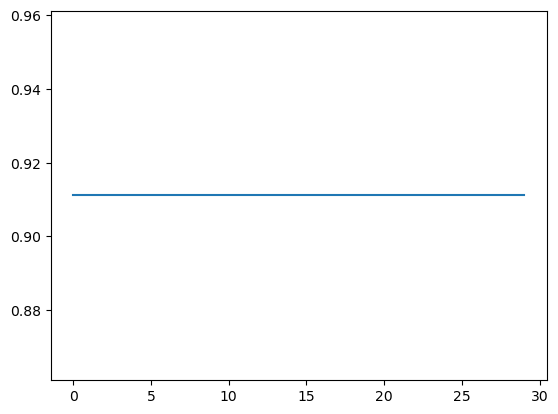

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x_iris, y_iris, test_size = 0.3, random_state = 42)
accuracy = np.zeros(30)
for rs in range(1, 31):
    kmeans = KMeans(n_clusters = 3, random_state = rs)
    kmeans.fit(x_train, y_train)
    y_pred = kmeans.predict(x_test)
    # 对齐标签以计算准确率
    y_pred_aligned = np.zeros_like(y_pred)
    for i in range(3):
        mask = (y_pred == i)
        true_labels = y_test[mask]
        if len(true_labels) == 0:
            continue
        most_common = Counter(true_labels).most_common(1)[0][0]
        y_pred_aligned[mask] = most_common
    y_pred = y_pred_aligned
    accuracy[rs - 1] = accuracy_score(y_test, y_pred)
plt.plot(accuracy)
plt.show()

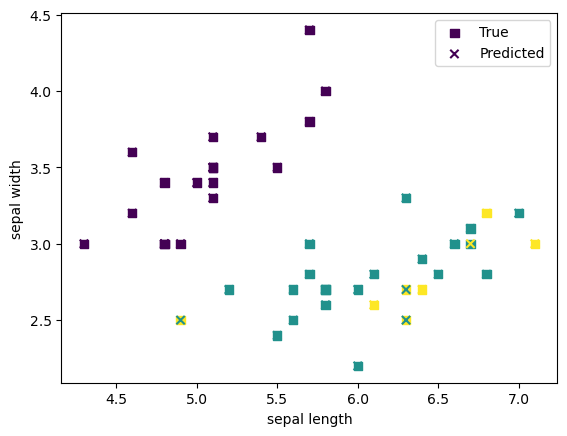

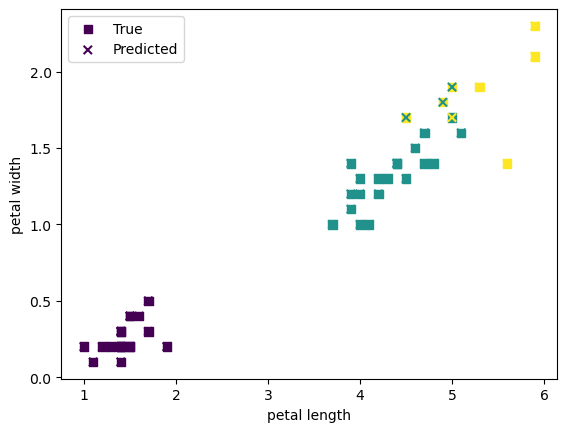

In [31]:
# 对前两个分量进行可视化
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='viridis', marker='s', label='True')
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_pred, cmap='viridis', marker='x', label='Predicted')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()
plt.show()
# 对后两个分量进行可视化
plt.scatter(x_test[:, 2], x_test[:, 3], c=y_test, cmap='viridis', marker='s', label='True')
plt.scatter(x_test[:, 2], x_test[:, 3], c=y_pred, cmap='viridis', marker='x', label='Predicted')
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.legend()
plt.show()

In [37]:
len(y_pred) * accuracy[0]

41.0

In [38]:
accuracy.mean()

0.9111111111111112